In [1]:
import time
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create camera sdk (ones!)
from src.pythorcam.camera_cs126 import create_camera_sdk
camerasdk = create_camera_sdk()

Camera 29236 is connected
Camera 29236 is disconnected
0.38567423820495605


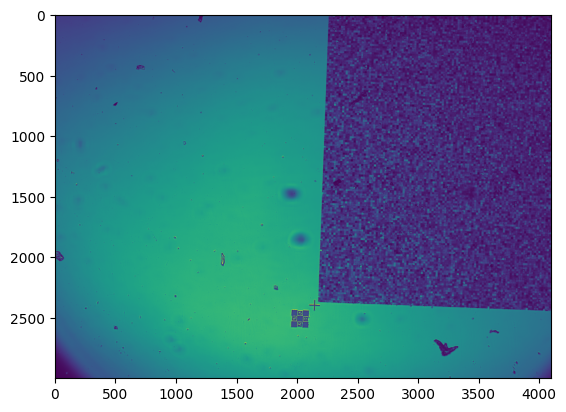

In [5]:
# Camera control
from src.pythorcam.camera_cs126 import Camera_CS126

serial_number = '29236'
Camera = Camera_CS126(camerasdk, serial_number)
Camera.Init_device()
Camera.Set_settings(exposure_time=300000, gain=0, black_level=5, bit_depth=np.uint16, out_bit_depth=np.float32)

Camera.Arm()
time.sleep(0.1)

start = time.time()
image = Camera.Get_image(Num_frames_to_average=1)
end = time.time()

#Continuous_capturing_with_plt(Camera, zoom_value=0.4)

Camera.Disarm()
Camera.Shutdown_device()

print(end - start)

plt.imshow(image)

In [2]:
# Monochromator
from src.monochromator.mono import MonochromatorControl

MonochromatorControl.list_available_ports()

['COM3', 'COM4']

In [3]:
monochromator = MonochromatorControl(port='COM4')

Connected to COM4; you can now initialize the Monochromator.


In [4]:
monochromator.initialize_arduino()

INFO: monochromator initialized; send `home` to start


In [5]:
monochromator.home_motor()

INFO: homing
ADC: 286
OK: homed


In [6]:
monochromator.select_grating_mode(mode="VIS Grating")

OK: mode VIS


In [12]:
monochromator.set_wavelength(wavelength=900)

INFO: moving 900.00
OK: wavelength 900.00


In [13]:
monochromator.disconnect()

Disconnected from Arduino.


In [8]:
# Check motors movement 
from pylablib.devices import Thorlabs

mm = 1e-3

xshift = Thorlabs.KinesisMotor("27271460", scale='stage')
xshift.setup_velocity(max_velocity=0.1*mm)
xshift.setup_velocity(acceleration=0.05*mm)
xshift.move_by(-1*mm) # movement in m
xshift.wait_move()
xshift.close()